In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Iris.csv")

In [3]:
x = pd.DataFrame(df.iloc[:,1:-1])
y = pd.DataFrame(df.iloc[:,-1])

In [4]:
x.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [6]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()

y_enc = y.apply(le.fit_transform)

print(le.classes_)

y_enc.head()

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,Species
0,0
1,0
2,0
3,0
4,0


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y_enc,test_size=0.2,random_state=42)

from sklearn import tree

model = tree.DecisionTreeClassifier(criterion="entropy", random_state=42)

model.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred = model.predict(x_test)

In [10]:
from sklearn import metrics

con_mat = metrics.confusion_matrix(y_pred, y_test)
print(con_mat)

print("Accuracy score=", metrics.accuracy_score(y_test, y_pred))
print("F1 score=", metrics.f1_score(y_test, y_pred, average="macro"))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy score= 1.0
F1 score= 1.0


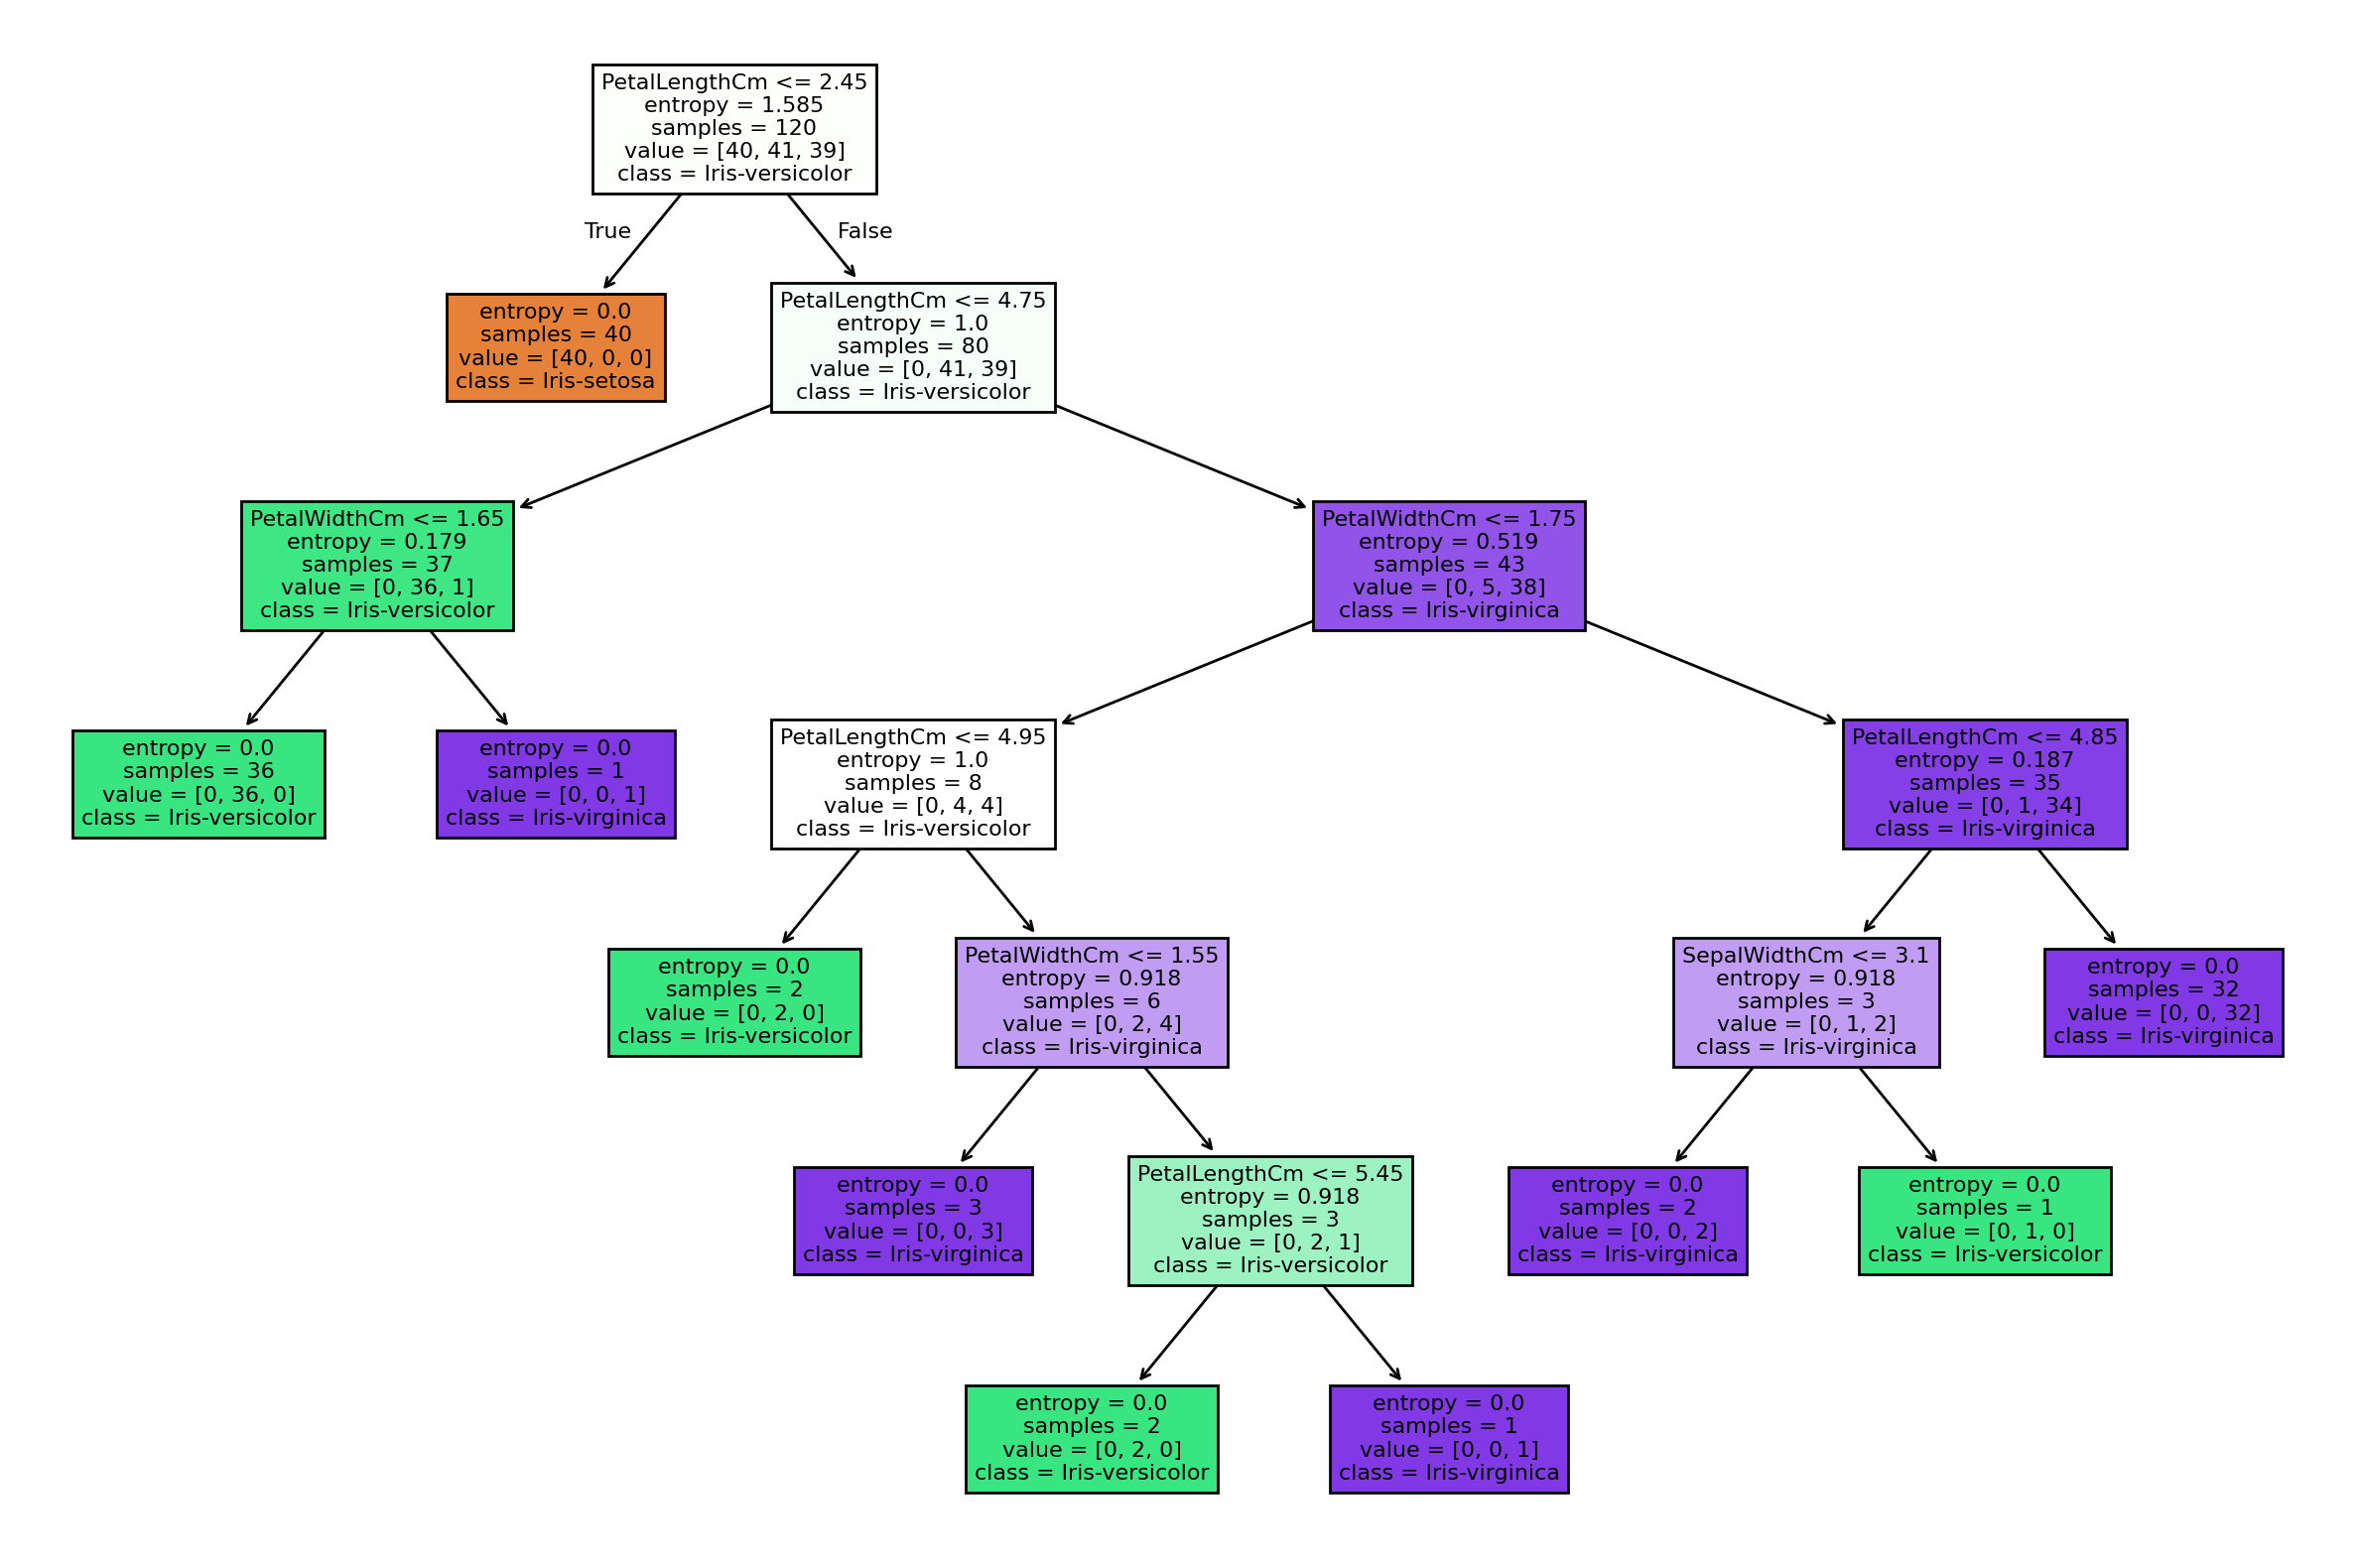

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8), dpi=200)
tree.plot_tree(model, class_names=le.classes_, feature_names= x.columns, filled=True)
plt.tight_layout()
plt.show()

In [12]:
print(le.classes_)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
